In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
df = pd.read_csv("mongolia_grid_10km.csv")


In [3]:
print(df.columns.tolist())

['system:index', 'changed_mean', 'changed_mode', 'degradation_mean', 'degradation_mode', 'lulc_early_mean', 'lulc_early_mode', 'lulc_recent_mean', 'lulc_recent_mode', 'net_change', 'recovery_mean', 'recovery_mode', '.geo']


In [4]:
cols = ["degradation_mean", "recovery_mean", "net_change", "changed_mean"]
print(df[cols].head())
print(df[cols].describe())

   degradation_mean  recovery_mean  net_change  changed_mean
0               NaN            NaN         0.0      0.000000
1               NaN            NaN         0.0      0.000000
2               0.0            0.0         0.0      0.152266
3               0.0            0.0         0.0      0.259939
4               NaN            NaN         0.0      0.000000
       degradation_mean  recovery_mean  net_change  changed_mean
count       6283.000000    6283.000000  7731.00000   7031.000000
mean           0.101839       0.070598    -0.02539      0.193102
std            0.205320       0.133624     0.21261      0.187766
min            0.000000       0.000000    -1.00000      0.000000
25%            0.000000       0.000000     0.00000      0.040000
50%            0.000000       0.006757     0.00000      0.147500
75%            0.083333       0.081081     0.01000      0.283750
max            1.000000       1.000000     1.00000      0.985714


In [5]:
print(df[cols].isna().sum())

degradation_mean    1448
recovery_mean       1448
net_change             0
changed_mean         700
dtype: int64


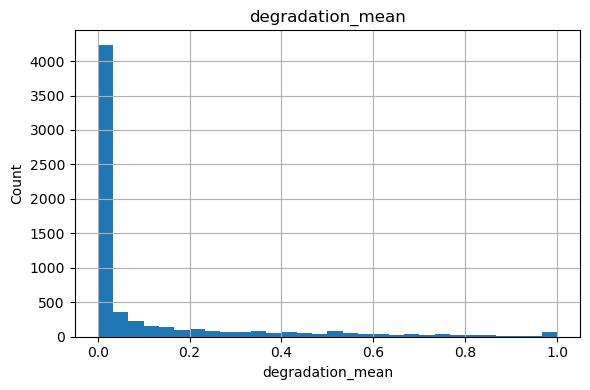

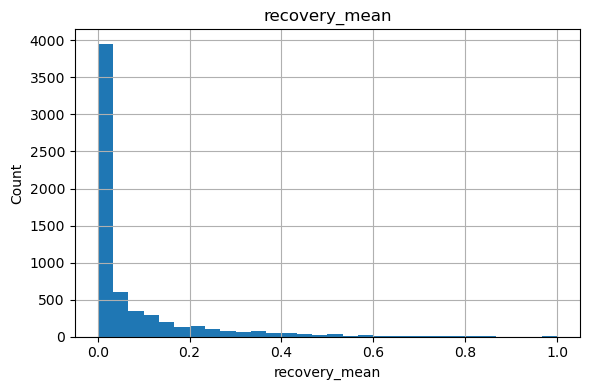

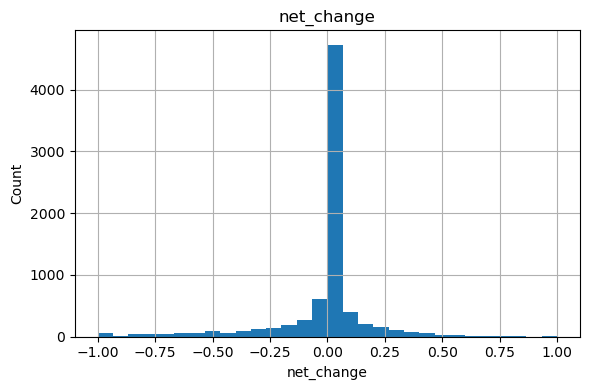

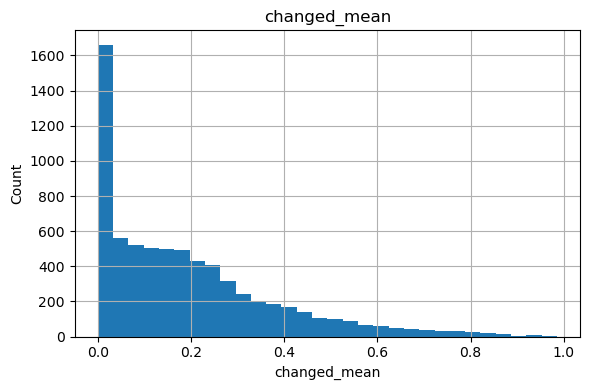

In [6]:
for col in ["degradation_mean", "recovery_mean", "net_change", "changed_mean"]:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [7]:
na_share = (df.isna().sum() / len(df) * 100).round(2)
print(na_share.sort_values(ascending=False))

degradation_mode    18.73
degradation_mean    18.73
recovery_mode       18.73
recovery_mean       18.73
changed_mode         9.05
lulc_recent_mode     9.05
changed_mean         9.05
lulc_early_mean      9.05
lulc_early_mode      9.05
lulc_recent_mean     9.05
system:index         0.00
net_change           0.00
.geo                 0.00
dtype: float64


In [8]:
for col in ["changed_mode", "degradation_mode", "recovery_mode",
            "lulc_early_mode", "lulc_recent_mode"]:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(10))


 changed_mode
changed_mode
0.0    6469
NaN     700
1.0     562
Name: count, dtype: int64

 degradation_mode
degradation_mode
0.0    5848
NaN    1448
1.0     435
Name: count, dtype: int64

 recovery_mode
recovery_mode
0.0    6160
NaN    1448
1.0     123
Name: count, dtype: int64

 lulc_early_mode
lulc_early_mode
7.0    3341
4.0    2502
2.0     985
NaN     700
1.0     104
5.0      77
8.0      12
6.0       6
0.0       3
7.0       1
Name: count, dtype: int64

 lulc_recent_mode
lulc_recent_mode
7.0    3454
4.0    2378
2.0    1001
NaN     700
1.0     106
5.0      78
6.0       7
8.0       3
0.0       3
7.0       1
Name: count, dtype: int64


In [9]:
df = pd.read_csv("mongolia_grid_10km.csv")

print("nature：", len(df))
print("\n列名：")
print(df.columns.tolist())

nature： 7731

列名：
['system:index', 'changed_mean', 'changed_mode', 'degradation_mean', 'degradation_mode', 'lulc_early_mean', 'lulc_early_mode', 'lulc_recent_mean', 'lulc_recent_mode', 'net_change', 'recovery_mean', 'recovery_mode', '.geo']


In [10]:
# 2. 先看 NA 占比
# =========================
na_share = (df.isna().sum() / len(df) * 100).round(2)
print("\nNA percentage（%）：")
print(na_share.sort_values(ascending=False))


NA percentage（%）：
degradation_mode    18.73
degradation_mean    18.73
recovery_mode       18.73
recovery_mean       18.73
changed_mode         9.05
lulc_recent_mode     9.05
changed_mean         9.05
lulc_early_mean      9.05
lulc_early_mode      9.05
lulc_recent_mean     9.05
system:index         0.00
net_change           0.00
.geo                 0.00
dtype: float64


In [11]:
# 3. 去掉真正空网格
# changed_mean 为 NA 的格网，说明这个格子本身没有有效像元
# =========================
df_clean = df[df["changed_mean"].notna()].copy()

print("\nNumber of rows after removing empty cells：", len(df_clean))


Number of rows after removing empty cells： 7031


In [12]:
# =========================
# 4. 把“无变化格网”的 NA 补成 0
# 如果 changed_mean = 0，但 degradation/recovery 是 NA，
# 这里不是坏数据，而是“没有变化”
# =========================
df_clean["degradation_mean"] = df_clean["degradation_mean"].fillna(0)
df_clean["recovery_mean"] = df_clean["recovery_mean"].fillna(0)


In [13]:
# 5. 构造更稳的 all-pixel 指标
# 原始 degradation_mean / recovery_mean 更像 changed pixels 内部比例
# 所以乘以 changed_mean，得到整个格网口径
# =========================
df_clean["degradation_share_allpx"] = (
    df_clean["changed_mean"] * df_clean["degradation_mean"]
)
df_clean["recovery_share_allpx"] = (
    df_clean["changed_mean"] * df_clean["recovery_mean"]
)
df_clean["net_change_allpx"] = (
    df_clean["recovery_share_allpx"] - df_clean["degradation_share_allpx"]
)

In [14]:
# 6. 先不重点解释这些列
# land-cover label 的 mean 没有很强解释意义
# 二值 mode 通常信息量也不如 mean
# =========================
drop_cols = [
    "lulc_early_mean",
    "lulc_recent_mean",
    "changed_mode",
    "degradation_mode",
    "recovery_mode"
]
drop_cols = [c for c in drop_cols if c in df_clean.columns]

df_model = df_clean.drop(columns=drop_cols)

In [15]:
# =========================
# 7. 看关键字段描述统计
# =========================
key_cols = [
    "changed_mean",
    "degradation_mean",
    "recovery_mean",
    "degradation_share_allpx",
    "recovery_share_allpx",
    "net_change_allpx"
]

print("\nKey fields describe():")
print(df_model[key_cols].describe())


Key fields describe():
       changed_mean  degradation_mean  recovery_mean  degradation_share_allpx  \
count   7031.000000       7031.000000    7031.000000              7031.000000   
mean       0.193102          0.091004       0.063087                 0.016156   
std        0.187766          0.196614       0.128177                 0.040993   
min        0.000000          0.000000       0.000000                 0.000000   
25%        0.040000          0.000000       0.000000                 0.000000   
50%        0.147500          0.000000       0.000000                 0.000000   
75%        0.283750          0.060976       0.065574                 0.007500   
max        0.985714          1.000000       1.000000                 0.480000   

       recovery_share_allpx  net_change_allpx  
count           7031.000000        7031.00000  
mean               0.012717          -0.00344  
std                0.029708           0.04757  
min                0.000000          -0.48000  
25%   

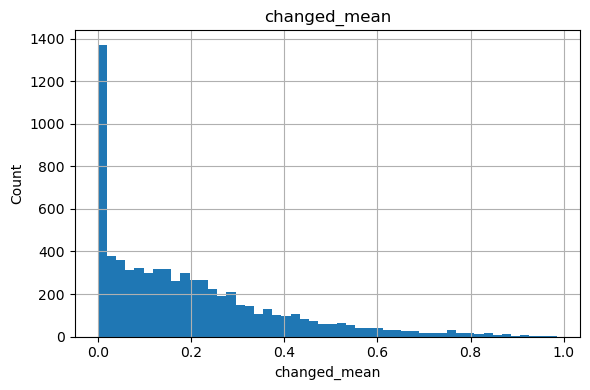

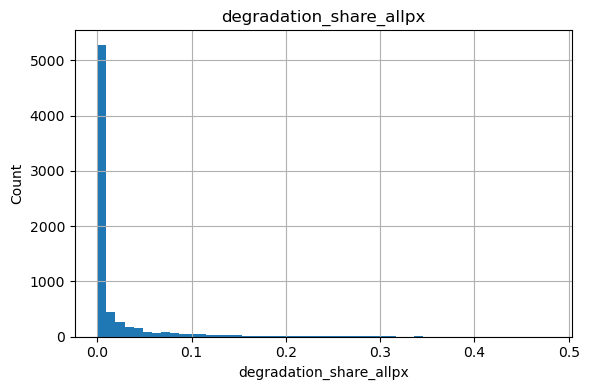

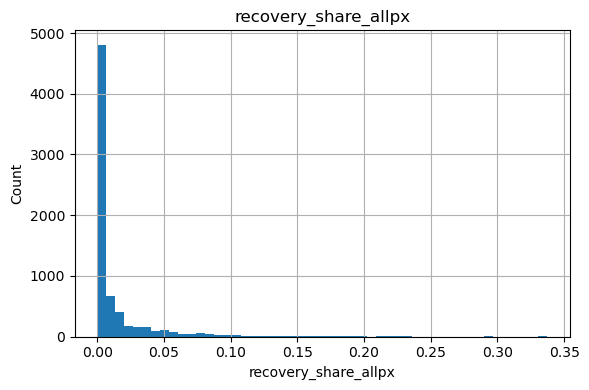

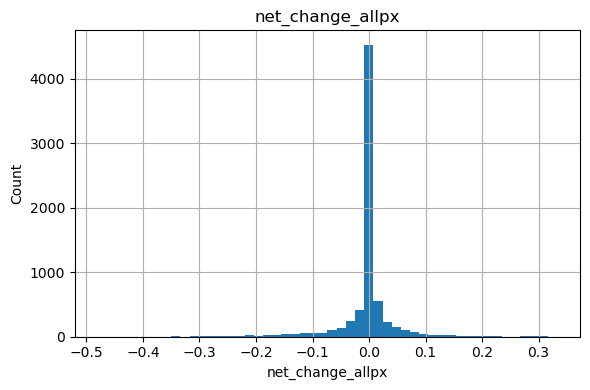

In [16]:

# =========================
# 8. 画你今天最需要的四张图
# =========================
for col in [
    "changed_mean",
    "degradation_share_allpx",
    "recovery_share_allpx",
    "net_change_allpx"
]:
    plt.figure(figsize=(6, 4))
    df_model[col].hist(bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

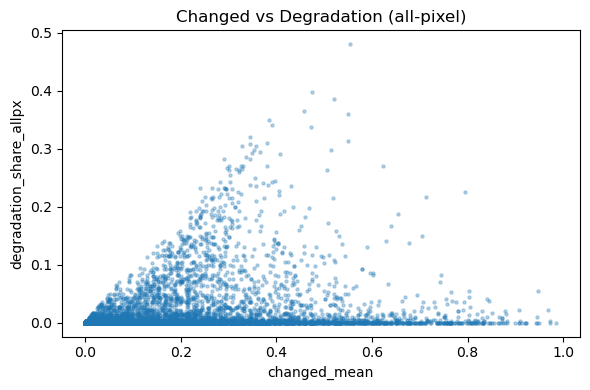

In [17]:
# =========================
# 9. 看“变化多”是不是等于“退化多”
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(
    df_model["changed_mean"],
    df_model["degradation_share_allpx"],
    s=5,
    alpha=0.3
)
plt.xlabel("changed_mean")
plt.ylabel("degradation_share_allpx")
plt.title("Changed vs Degradation (all-pixel)")
plt.tight_layout()
plt.show()

In [18]:
print(df_model[["changed_mean", "degradation_share_allpx"]].corr(method="pearson"))
print(df_model[["changed_mean", "degradation_share_allpx"]].corr(method="spearman"))

                         changed_mean  degradation_share_allpx
changed_mean                 1.000000                 0.190251
degradation_share_allpx      0.190251                 1.000000
                         changed_mean  degradation_share_allpx
changed_mean                 1.000000                 0.329313
degradation_share_allpx      0.329313                 1.000000


           changed_bin      mean  count   bin_mid
0  (-0.000986, 0.0493]  0.001356   1938  0.024157
1     (0.0493, 0.0986]  0.006624    805  0.073950
2      (0.0986, 0.148]  0.011099    781  0.123300
3       (0.148, 0.197]  0.018875    716  0.172500
4       (0.197, 0.246]  0.029626    652  0.221500


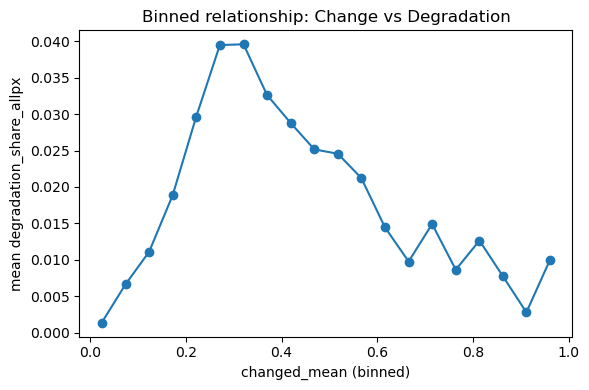

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 只保留要用的两列，去掉缺失
tmp = df_model[["changed_mean", "degradation_share_allpx"]].dropna().copy()

# 把 changed_mean 分成 20 个箱
tmp["changed_bin"] = pd.cut(tmp["changed_mean"], bins=20)

# 每个箱里，计算平均退化比例和样本数
bin_stats = (
    tmp.groupby("changed_bin", observed=False)["degradation_share_allpx"]
    .agg(["mean", "count"])
    .reset_index()
)

# 取每个区间的中点，方便画线
bin_stats["bin_mid"] = bin_stats["changed_bin"].apply(lambda x: x.mid)

print(bin_stats.head())

# 画分箱平均线
plt.figure(figsize=(6, 4))
plt.plot(bin_stats["bin_mid"], bin_stats["mean"], marker="o")
plt.xlabel("changed_mean (binned)")
plt.ylabel("mean degradation_share_allpx")
plt.title("Binned relationship: Change vs Degradation")
plt.tight_layout()
plt.show()

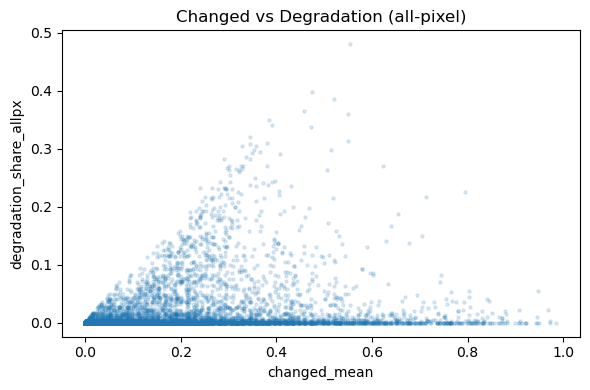

In [20]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df_model["changed_mean"],
    df_model["degradation_share_allpx"],
    s=5,
    alpha=0.15
)
plt.xlabel("changed_mean")
plt.ylabel("degradation_share_allpx")
plt.title("Changed vs Degradation (all-pixel)")
plt.tight_layout()
plt.show()

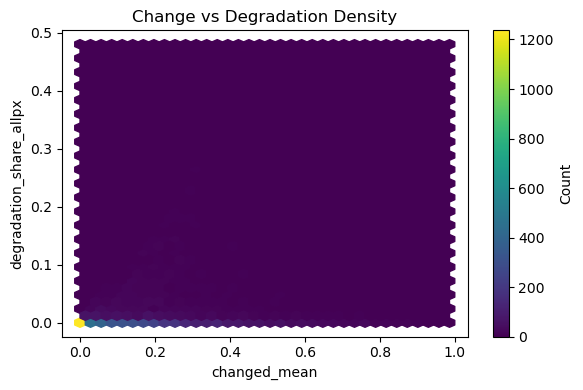

In [21]:
plt.figure(figsize=(6, 4))
plt.hexbin(
    df_model["changed_mean"],
    df_model["degradation_share_allpx"],
    gridsize=35
)
plt.xlabel("changed_mean")
plt.ylabel("degradation_share_allpx")
plt.title("Change vs Degradation Density")
plt.colorbar(label="Count")
plt.tight_layout()
plt.show()

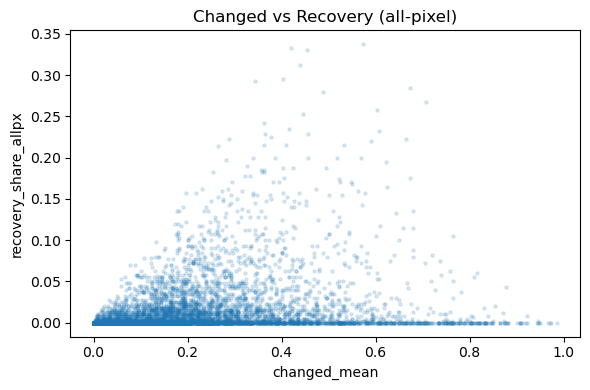

                      changed_mean  recovery_share_allpx
changed_mean              1.000000              0.262184
recovery_share_allpx      0.262184              1.000000
                      changed_mean  recovery_share_allpx
changed_mean              1.000000              0.414452
recovery_share_allpx      0.414452              1.000000


In [22]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df_model["changed_mean"],
    df_model["recovery_share_allpx"],
    s=5,
    alpha=0.15
)
plt.xlabel("changed_mean")
plt.ylabel("recovery_share_allpx")
plt.title("Changed vs Recovery (all-pixel)")
plt.tight_layout()
plt.show()

print(df_model[["changed_mean", "recovery_share_allpx"]].corr(method="pearson"))
print(df_model[["changed_mean", "recovery_share_allpx"]].corr(method="spearman"))

           changed_bin      mean  count   bin_mid
0  (-0.000986, 0.0493]  0.000775   1938  0.024157
1     (0.0493, 0.0986]  0.004651    805  0.073950
2      (0.0986, 0.148]  0.009126    781  0.123300
3       (0.148, 0.197]  0.014883    716  0.172500
4       (0.197, 0.246]  0.019043    652  0.221500


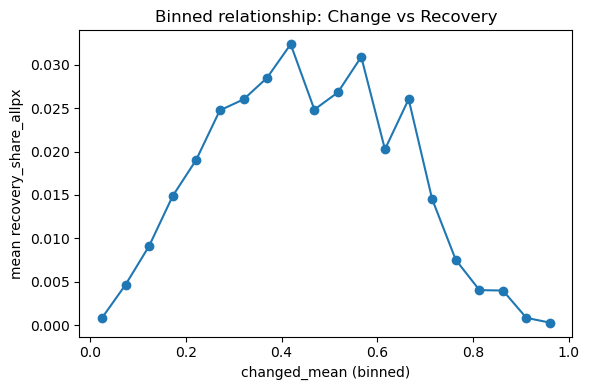

In [23]:
# changed_mean vs recovery_share_allpx 分箱平均线

import pandas as pd
import matplotlib.pyplot as plt

tmp = df_model[["changed_mean", "recovery_share_allpx"]].dropna().copy()

# 分 20 个箱
tmp["changed_bin"] = pd.cut(tmp["changed_mean"], bins=20)

# 每个箱的平均 recovery 和样本数
bin_stats_rec = (
    tmp.groupby("changed_bin", observed=False)["recovery_share_allpx"]
    .agg(["mean", "count"])
    .reset_index()
)

# 取区间中点作为 x
bin_stats_rec["bin_mid"] = bin_stats_rec["changed_bin"].apply(lambda x: x.mid)

print(bin_stats_rec.head())

# 画图
plt.figure(figsize=(6, 4))
plt.plot(bin_stats_rec["bin_mid"], bin_stats_rec["mean"], marker="o")
plt.xlabel("changed_mean (binned)")
plt.ylabel("mean recovery_share_allpx")
plt.title("Binned relationship: Change vs Recovery")
plt.tight_layout()
plt.show()

In [24]:
print(df_model[["changed_mean", "recovery_share_allpx"]].corr(method="pearson"))
print(df_model[["changed_mean", "recovery_share_allpx"]].corr(method="spearman"))

                      changed_mean  recovery_share_allpx
changed_mean              1.000000              0.262184
recovery_share_allpx      0.262184              1.000000
                      changed_mean  recovery_share_allpx
changed_mean              1.000000              0.414452
recovery_share_allpx      0.414452              1.000000


In [25]:
# =========================
# 10. 找最退化的格网
# =========================
worst_cells = df_model.sort_values("net_change_allpx").head(20)
print("\n最强净退化格网：")
print(
    worst_cells[
        [
            "net_change_allpx",
            "degradation_share_allpx",
            "recovery_share_allpx",
            "changed_mean",
            "lulc_early_mode",
            "lulc_recent_mode"
        ]
    ]
)



最强净退化格网：
      net_change_allpx  degradation_share_allpx  recovery_share_allpx  \
5957         -0.480000                 0.480000              0.000000   
5026         -0.385000                 0.385000              0.000000   
5506         -0.382500                 0.397500              0.015000   
5731         -0.360000                 0.360000              0.000000   
3075         -0.350000                 0.350000              0.000000   
3071         -0.340000                 0.340000              0.000000   
4181         -0.332500                 0.365000              0.032500   
4182         -0.315791                 0.320764              0.004973   
5729         -0.315000                 0.337500              0.022500   
4803         -0.310000                 0.310000              0.000000   
3958         -0.300000                 0.305000              0.005000   
2625         -0.295000                 0.305000              0.010000   
3074         -0.295000                 0.

In [26]:
# =========================
# 11. 找退化比例最高的格网
# =========================
top_deg = df_model.sort_values("degradation_share_allpx", ascending=False).head(20)
print("\n退化比例最高格网：")
print(
    top_deg[
        [
            "degradation_share_allpx",
            "net_change_allpx",
            "recovery_share_allpx",
            "changed_mean",
            "lulc_early_mode",
            "lulc_recent_mode"
        ]
    ]
)



退化比例最高格网：
      degradation_share_allpx  net_change_allpx  recovery_share_allpx  \
5957                 0.480000         -0.480000              0.000000   
5506                 0.397500         -0.382500              0.015000   
5026                 0.385000         -0.385000              0.000000   
4181                 0.365000         -0.332500              0.032500   
5731                 0.360000         -0.360000              0.000000   
3075                 0.350000         -0.350000              0.000000   
3071                 0.340000         -0.340000              0.000000   
5729                 0.337500         -0.315000              0.022500   
4182                 0.320764         -0.315791              0.004973   
5044                 0.312500         -0.290000              0.022500   
4803                 0.310000         -0.310000              0.000000   
5737                 0.307500         -0.295000              0.012500   
3958                 0.305000         -0

In [27]:
# 1. top lists overlap
worst_idx = set(worst_cells.index)
top_deg_idx = set(top_deg.index)

overlap = worst_idx.intersection(top_deg_idx)
print("重合数量：", len(overlap))
print("重合格网索引：", sorted(list(overlap)))

重合数量： 19
重合格网索引： [2625, 3071, 3074, 3075, 3078, 3517, 3958, 4181, 4182, 4803, 5026, 5044, 5061, 5506, 5729, 5730, 5731, 5737, 5957]


In [28]:
# 2. mode cross-tab
print(pd.crosstab(top_deg["lulc_early_mode"], top_deg["lulc_recent_mode"]))
print(pd.crosstab(worst_cells["lulc_early_mode"], worst_cells["lulc_recent_mode"]))

lulc_recent_mode  2.0  7.0
lulc_early_mode           
2.0                 1   14
5.0                 0    3
7.0                 0    2
lulc_recent_mode  2.0  7.0
lulc_early_mode           
2.0                 1   13
5.0                 0    3
7.0                 0    3


In [29]:
threshold_deg = df_model["degradation_share_allpx"].quantile(0.95)
top5_deg = df_model[df_model["degradation_share_allpx"] >= threshold_deg].copy()

print("top 5% 退化阈值：", threshold_deg)
print("top 5% 格网数量：", len(top5_deg))

top 5% 退化阈值： 0.09999999999999998
top 5% 格网数量： 353


In [30]:
threshold_net = df_model["net_change_allpx"].quantile(0.05)
top5_worst = df_model[df_model["net_change_allpx"] <= threshold_net].copy()

print("top 5% 净退化阈值：", threshold_net)
print("top 5% 格网数量：", len(top5_worst))

top 5% 净退化阈值： -0.07750000000000001
top 5% 格网数量： 353


In [31]:
overlap_5 = set(top5_deg.index).intersection(set(top5_worst.index))

print("top 5% overlap 数量：", len(overlap_5))
print("overlap 占退化top5%的比例：", len(overlap_5) / len(top5_deg))
print("overlap 占净退化top5%的比例：", len(overlap_5) / len(top5_worst))

top 5% overlap 数量： 315
overlap 占退化top5%的比例： 0.8923512747875354
overlap 占净退化top5%的比例： 0.8923512747875354


In [32]:
# =========================
# 10A. 定义 top 5% 退化热点
# =========================
deg_threshold = df_model["degradation_share_allpx"].quantile(0.95)
top5_deg = df_model[df_model["degradation_share_allpx"] >= deg_threshold].copy()

print("退化热点阈值（top 5%）:", deg_threshold)
print("退化热点数量:", len(top5_deg))

print(
    top5_deg[
        [
            "degradation_share_allpx",
            "net_change_allpx",
            "recovery_share_allpx",
            "changed_mean",
            "lulc_early_mode",
            "lulc_recent_mode"
        ]
    ].sort_values("degradation_share_allpx", ascending=False).head(20)
)

退化热点阈值（top 5%）: 0.09999999999999998
退化热点数量: 353
      degradation_share_allpx  net_change_allpx  recovery_share_allpx  \
5957                 0.480000         -0.480000              0.000000   
5506                 0.397500         -0.382500              0.015000   
5026                 0.385000         -0.385000              0.000000   
4181                 0.365000         -0.332500              0.032500   
5731                 0.360000         -0.360000              0.000000   
3075                 0.350000         -0.350000              0.000000   
3071                 0.340000         -0.340000              0.000000   
5729                 0.337500         -0.315000              0.022500   
4182                 0.320764         -0.315791              0.004973   
5044                 0.312500         -0.290000              0.022500   
4803                 0.310000         -0.310000              0.000000   
5737                 0.307500         -0.295000              0.012500   
262

In [33]:
# =========================
# 10B. 定义 top 5% 净退化热点
# 最负的 5%，所以用 0.05 分位数
# =========================
net_threshold = df_model["net_change_allpx"].quantile(0.05)
top5_worst = df_model[df_model["net_change_allpx"] <= net_threshold].copy()

print("净退化热点阈值（bottom 5%）:", net_threshold)
print("净退化热点数量:", len(top5_worst))

print(
    top5_worst[
        [
            "net_change_allpx",
            "degradation_share_allpx",
            "recovery_share_allpx",
            "changed_mean",
            "lulc_early_mode",
            "lulc_recent_mode"
        ]
    ].sort_values("net_change_allpx").head(20)
)

净退化热点阈值（bottom 5%）: -0.07750000000000001
净退化热点数量: 353
      net_change_allpx  degradation_share_allpx  recovery_share_allpx  \
5957         -0.480000                 0.480000              0.000000   
5026         -0.385000                 0.385000              0.000000   
5506         -0.382500                 0.397500              0.015000   
5731         -0.360000                 0.360000              0.000000   
3075         -0.350000                 0.350000              0.000000   
3071         -0.340000                 0.340000              0.000000   
4181         -0.332500                 0.365000              0.032500   
4182         -0.315791                 0.320764              0.004973   
5729         -0.315000                 0.337500              0.022500   
4803         -0.310000                 0.310000              0.000000   
3958         -0.300000                 0.305000              0.005000   
3074         -0.295000                 0.297500              0.002500 

In [34]:
# =========================
# 11. 看两个 5% hotspot 集合的 overlap
# =========================
worst_idx_5 = set(top5_worst.index)
top_deg_idx_5 = set(top5_deg.index)

overlap_5 = worst_idx_5.intersection(top_deg_idx_5)

print("top 5% overlap 数量:", len(overlap_5))
print("overlap 占退化热点比例:", len(overlap_5) / len(top5_deg))
print("overlap 占净退化热点比例:", len(overlap_5) / len(top5_worst))
print("重合格网索引前 30 个:", sorted(list(overlap_5))[:30])

top 5% overlap 数量: 315
overlap 占退化热点比例: 0.8923512747875354
overlap 占净退化热点比例: 0.8923512747875354
重合格网索引前 30 个: [1955, 1962, 2176, 2179, 2180, 2182, 2183, 2184, 2398, 2399, 2400, 2401, 2405, 2406, 2407, 2408, 2409, 2410, 2622, 2623, 2624, 2625, 2626, 2627, 2628, 2629, 2630, 2631, 2844, 2847]


In [35]:
# =========================
# 12. 5% hotspot 的 mode cross-tab
# =========================
print("top 5% degradation hotspots:")
print(pd.crosstab(top5_deg["lulc_early_mode"], top5_deg["lulc_recent_mode"]))

print("\nbottom 5% net-change hotspots:")
print(pd.crosstab(top5_worst["lulc_early_mode"], top5_worst["lulc_recent_mode"]))

top 5% degradation hotspots:
lulc_recent_mode  1.0  2.0  4.0  5.0  7.0
lulc_early_mode                          
1.0                 1    0    0    0    0
2.0                 1   95   10    1   90
4.0                 0    0    2    0    8
5.0                 1    1    3    3   11
7.0                 0    1    2    0  123

bottom 5% net-change hotspots:
lulc_recent_mode  1.0  2.0  4.0  5.0  7.0
lulc_early_mode                          
1.0                 1    0    0    0    0
2.0                 1  102   11    0   86
4.0                 0    0    3    0   11
5.0                 2    1    3    3   11
7.0                 0    0    2    0  116


In [36]:
# =========================
# 13. 核心热点：同时属于两类 5%
# =========================
core_hotspots = df_model.loc[df_model.index.isin(overlap_5)].copy()

print("核心热点数量:", len(core_hotspots))

print(
    core_hotspots[
        [
            "degradation_share_allpx",
            "net_change_allpx",
            "recovery_share_allpx",
            "changed_mean",
            "lulc_early_mode",
            "lulc_recent_mode"
        ]
    ].sort_values("degradation_share_allpx", ascending=False).head(20)
)

核心热点数量: 315
      degradation_share_allpx  net_change_allpx  recovery_share_allpx  \
5957                 0.480000         -0.480000              0.000000   
5506                 0.397500         -0.382500              0.015000   
5026                 0.385000         -0.385000              0.000000   
4181                 0.365000         -0.332500              0.032500   
5731                 0.360000         -0.360000              0.000000   
3075                 0.350000         -0.350000              0.000000   
3071                 0.340000         -0.340000              0.000000   
5729                 0.337500         -0.315000              0.022500   
4182                 0.320764         -0.315791              0.004973   
5044                 0.312500         -0.290000              0.022500   
4803                 0.310000         -0.310000              0.000000   
5737                 0.307500         -0.295000              0.012500   
2625                 0.305000         -

In [37]:
import matplotlib.pyplot as plt

In [41]:
gdf = gpd.read_file("mongolia_grid_10km.geojson")

print(gdf.shape)
print(gdf.columns.tolist())


(7731, 13)
['id', 'changed_mean', 'changed_mode', 'degradation_mean', 'degradation_mode', 'lulc_early_mean', 'lulc_early_mode', 'lulc_recent_mean', 'lulc_recent_mode', 'net_change', 'recovery_mean', 'recovery_mode', 'geometry']


In [45]:
gdf_model = gdf[gdf["changed_mean"].notna()].copy()

In [46]:
print(gdf_model.shape)

(7031, 13)


In [47]:
# 无变化格网补 0
gdf_model["degradation_mean"] = gdf_model["degradation_mean"].fillna(0)
gdf_model["recovery_mean"] = gdf_model["recovery_mean"].fillna(0)


In [58]:
# whole-grid 指标
gdf_model["degradation_share_allpx"] = (
    gdf_model["changed_mean"] * gdf_model["degradation_mean"]
)
gdf_model["recovery_share_allpx"] = (
    gdf_model["changed_mean"] * gdf_model["recovery_mean"]
)
gdf_model["net_change_allpx"] = (
    gdf_model["recovery_share_allpx"] - gdf_model["degradation_share_allpx"]
)

print(gdf_model.shape)
print(
    gdf_model[
        [
            "changed_mean",
            "degradation_share_allpx",
            "recovery_share_allpx",
            "net_change_allpx"
        ]
    ].describe()
)

(7031, 19)
       changed_mean  degradation_share_allpx  recovery_share_allpx  \
count   7031.000000              7031.000000           7031.000000   
mean       0.193102                 0.016156              0.012717   
std        0.187766                 0.040993              0.029708   
min        0.000000                 0.000000              0.000000   
25%        0.040000                 0.000000              0.000000   
50%        0.147500                 0.000000              0.000000   
75%        0.283750                 0.007500              0.010000   
max        0.985714                 0.480000              0.337500   

       net_change_allpx  
count        7031.00000  
mean           -0.00344  
std             0.04757  
min            -0.48000  
25%            -0.00250  
50%             0.00000  
75%             0.00250  
max             0.33250  


In [55]:
# 用之前已经算出来的精确阈值
threshold_deg = 0.09999999999999998
threshold_net = -0.07750000000000001

df_model["is_deg_hotspot_5"] = (
    df_model["degradation_share_allpx"] >= threshold_deg
).astype(int)

df_model["is_netdeg_hotspot_5"] = (
    df_model["net_change_allpx"] <= threshold_net
).astype(int)

df_model["is_core_hotspot"] = (
    (df_model["is_deg_hotspot_5"] == 1) &
    (df_model["is_netdeg_hotspot_5"] == 1)
).astype(int)

print(df_model["is_deg_hotspot_5"].sum())
print(df_model["is_netdeg_hotspot_5"].sum())
print(df_model["is_core_hotspot"].sum())

353
353
315


In [57]:
# 先确保两边顺序一致
df_model = df_model.reset_index(drop=True)
gdf_model = gdf_model.reset_index(drop=True)

print(len(df_model), len(gdf_model))

7031 7031


In [56]:
df_model = df_model.reset_index(drop=True)
gdf_model = gdf_model.reset_index(drop=True)

gdf_model["is_deg_hotspot_5"] = df_model["is_deg_hotspot_5"]
gdf_model["is_netdeg_hotspot_5"] = df_model["is_netdeg_hotspot_5"]
gdf_model["is_core_hotspot"] = df_model["is_core_hotspot"]

print(gdf_model["is_deg_hotspot_5"].sum())
print(gdf_model["is_netdeg_hotspot_5"].sum())
print(gdf_model["is_core_hotspot"].sum())

353
353
315


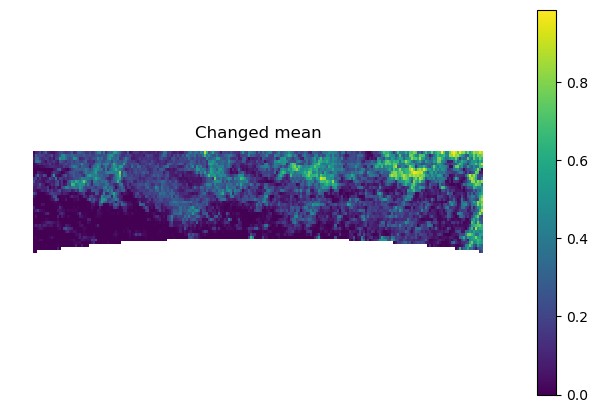

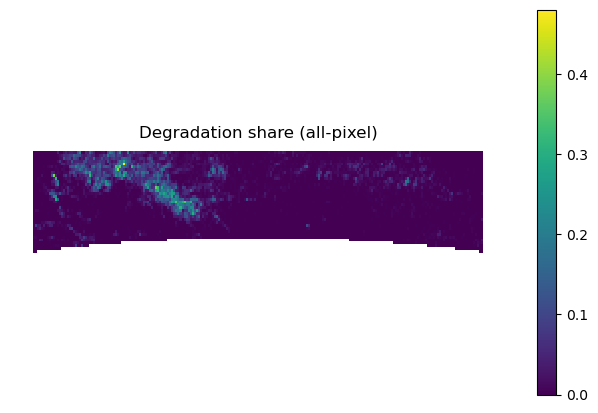

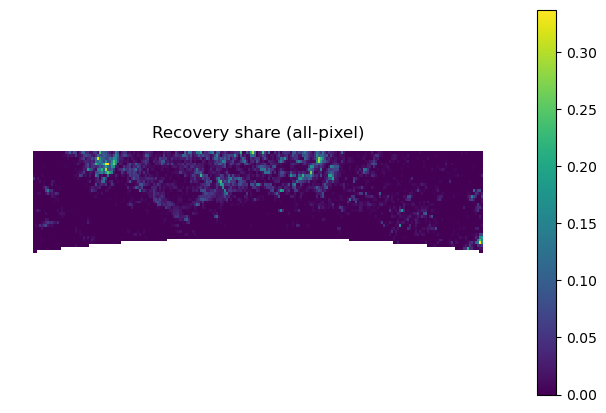

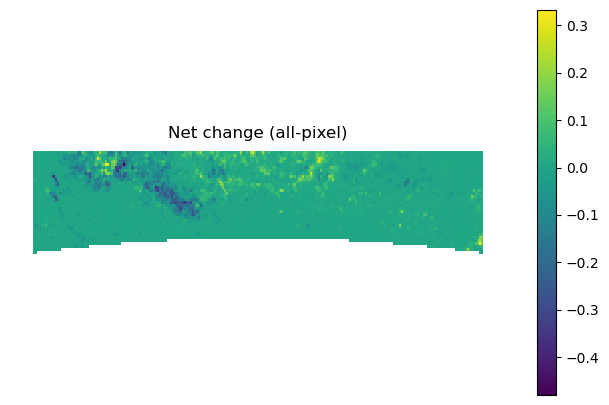

In [60]:
#背景分布图
for col, title in [
    ("changed_mean", "Changed mean"),
    ("degradation_share_allpx", "Degradation share (all-pixel)"),
    ("recovery_share_allpx", "Recovery share (all-pixel)"),
    ("net_change_allpx", "Net change (all-pixel)")
]:
    ax = gdf_model.plot(column=col, legend=True, figsize=(8, 5))
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

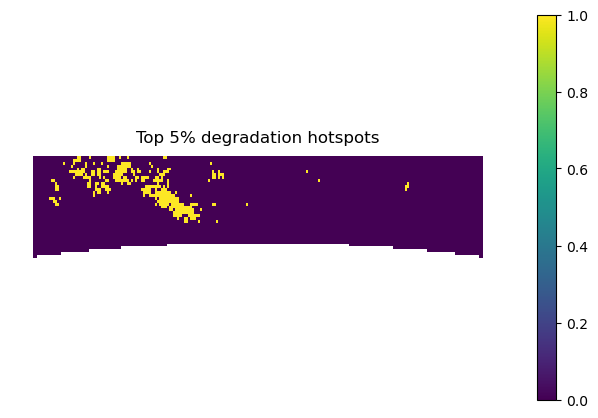

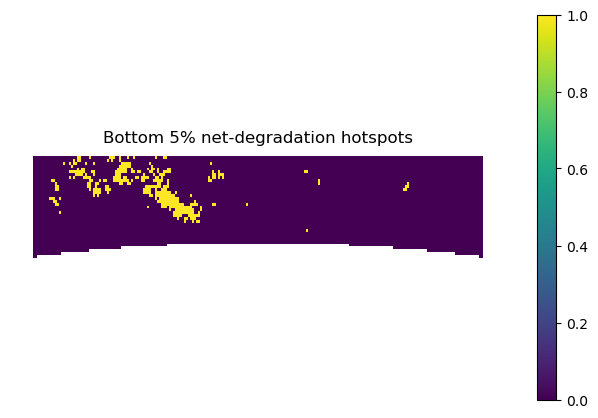

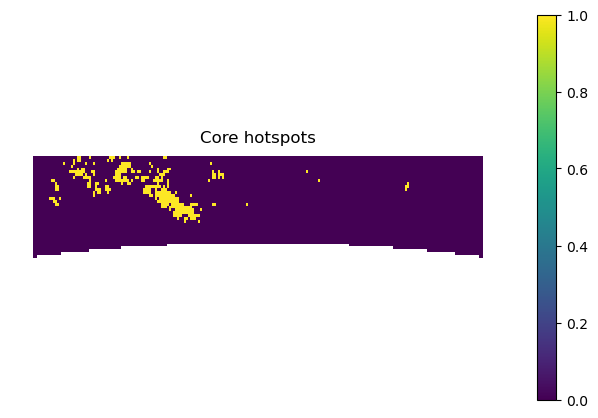

In [61]:
#热点
for col, title in [
    ("is_deg_hotspot_5", "Top 5% degradation hotspots"),
    ("is_netdeg_hotspot_5", "Bottom 5% net-degradation hotspots"),
    ("is_core_hotspot", "Core hotspots")
]:
    ax = gdf_model.plot(column=col, legend=True, figsize=(8, 5))
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

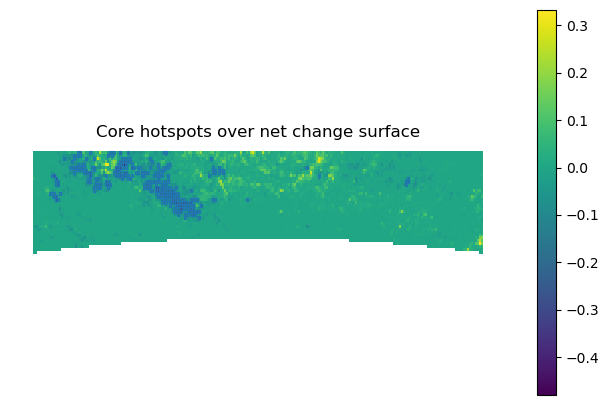

In [62]:
#叠加：
ax = gdf_model.plot(column="net_change_allpx", legend=True, figsize=(8, 5))
gdf_model[gdf_model["is_core_hotspot"] == 1].boundary.plot(ax=ax, linewidth=0.8)
ax.set_title("Core hotspots over net change surface")
ax.set_axis_off()
plt.show()

In [64]:
# 看看分布
# 先投影到平面坐标系
gdf_proj = gdf_model.to_crs("EPSG:3857").copy()

# 在投影坐标系里算 centroid
gdf_proj["centroid"] = gdf_proj.geometry.centroid

# 如果你还想要经纬度，再转回 WGS84
centroids_wgs84 = gdf_proj["centroid"].to_crs("EPSG:4326")

gdf_model["centroid_x"] = centroids_wgs84.x
gdf_model["centroid_y"] = centroids_wgs84.y

# 按中位数纬度分南北
lat_mid = gdf_model["centroid_y"].median()

gdf_model["ns_half"] = gdf_model["centroid_y"].apply(
    lambda y: "north" if y >= lat_mid else "south"
)

summary_ns = gdf_model.groupby("ns_half")[
    [
        "changed_mean",
        "degradation_share_allpx",
        "recovery_share_allpx",
        "net_change_allpx",
        "is_deg_hotspot_5",
        "is_netdeg_hotspot_5",
        "is_core_hotspot"
    ]
].mean()

print(summary_ns)



         changed_mean  degradation_share_allpx  recovery_share_allpx  \
ns_half                                                                
north        0.274553                 0.024671              0.020827   
south        0.108414                 0.007304              0.004283   

         net_change_allpx  is_deg_hotspot_5  is_netdeg_hotspot_5  \
ns_half                                                            
north           -0.003843          0.077009             0.076172   
south           -0.003020          0.022338             0.023209   

         is_core_hotspot  
ns_half                   
north           0.067801  
south           0.020888  


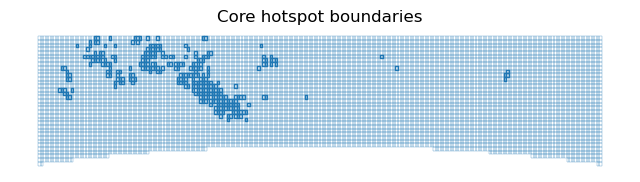

In [65]:
#热点成片吗
core = gdf_model[gdf_model["is_core_hotspot"] == 1].copy()

ax = gdf_model.boundary.plot(figsize=(8, 5), linewidth=0.2)
core.boundary.plot(ax=ax, linewidth=1.0)
ax.set_title("Core hotspot boundaries")
ax.set_axis_off()
plt.show()

In [66]:
#我们的target设定为target_main = "degradation_share_allpx"
target_main = "degradation_share_allpx"
target_aux = "net_change_allpx"
target_binary = "is_deg_hotspot_5"
target_core = "is_core_hotspot"

print(target_main, target_aux, target_binary, target_core)

degradation_share_allpx net_change_allpx is_deg_hotspot_5 is_core_hotspot


In [68]:
# 去掉不必要列
export_cols = [
    "changed_mean",
    "degradation_mean",
    "recovery_mean",
    "degradation_share_allpx",
    "recovery_share_allpx",
    "net_change_allpx",
    "is_deg_hotspot_5",
    "is_netdeg_hotspot_5",
    "is_core_hotspot",
    "lulc_early_mode",
    "lulc_recent_mode",
    "geometry"
]

gdf_export = gdf_model[export_cols].copy()

gdf_export.to_file(
    "mongolia_grid_10km_cleaned.geojson",
    driver="GeoJSON"
)

print("已导出 cleaned geojson")

已导出 cleaned geojson


In [59]:
print((gdf_model["degradation_share_allpx"] == deg_threshold).sum())
print((gdf_model["net_change_allpx"] == net_threshold).sum())

print(gdf_model["degradation_share_allpx"].sort_values().tail(10))
print(gdf_model["net_change_allpx"].sort_values().head(10))

9
6
5043    0.312500
4181    0.320764
5728    0.337500
3070    0.340000
3074    0.350000
5730    0.360000
4180    0.365000
5025    0.385000
5505    0.397500
5956    0.480000
Name: degradation_share_allpx, dtype: float64
5956   -0.480000
5025   -0.385000
5505   -0.382500
5730   -0.360000
3074   -0.350000
3070   -0.340000
4180   -0.332500
4181   -0.315791
5728   -0.315000
4802   -0.310000
Name: net_change_allpx, dtype: float64
